In [ ]:
from proteomeScoutAPI import ProteomeScoutAPI
import pandas as pd
import matplotlib.pyplot as plt

PTM_API = ProteomeScoutAPI()




In [ ]:
# Let's get all modifications for a single species, in this case human
species_ids, species_type = PTM_API.return_species_nr_uniprot_ids()
human_ids = species_ids['Homo sapiens']
df_all = pd.DataFrame()
for ID in human_ids:
    table = PTM_API.get_annotated_PTMs(ID)
    df_all = pd.concat([df_all, table], ignore_index=True)

In [ ]:
# lets' group df_all into individual modification types, then count all together and those not in domains, and fraction in domains
dict_mods = {}
for name, group in df_all.groupby('Modification_Type'):
    not_in_domain = group[group['InterPro_IDs'].isna() | (group['InterPro_IDs'] == '')]
    dict_mods[name] = [len(group), len(not_in_domain), (len(group) - len(not_in_domain))/len(group) if len(group) > 0 else 0]


Acetylation: 0.41
Malonylation: 0.51
Methylation: 0.30
N-Glycosylation: 0.55
N6-acetyllysine: 0.50
N6-succinyllysine: 0.57
O-Glycosylation: 0.16
Phosphoserine: 0.24
Phosphothreonine: 0.32
Phosphotyrosine: 0.44
Sulfoxidation: 0.45
Sumoylation: 0.33
Ubiquitination: 0.43


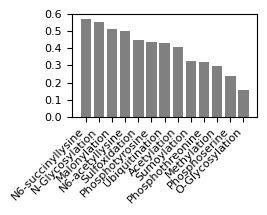

In [ ]:

# Let's plot a normalized bar plot for mods with more than minimum number
# it shows the fraction of modifications that are in domains (that's the 2 index in the list of a dict item)
min_num_mods = 2000

fract_dict = {}
for mod in dict_mods:
    if dict_mods[mod][0] > min_num_mods:
        print(f"{mod}: {dict_mods[mod][2]:.2f}")
        fract_dict[mod] = dict_mods[mod][2]

# sort fract_dict by the fraction of mods in domains
# set the figure size and 
plt.figure(figsize=(2.75, 2.25))

sorted_fract_dict = dict(sorted(fract_dict.items(), key=lambda item: item[1], reverse=True))

ax = plt.gca()
ax.set_ylim(0, 0.6)
ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
# set the bar eight as 1.0, or 100%
plt.bar(sorted_fract_dict.keys(), sorted_fract_dict.values(), color='gray')   
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
#plt.ylabel('Fraction of Modifications in Domains', fontsize=8)
#plt.xlabel('Modification Types', fontsize=8)
plt.tight_layout()
plt.savefig("modifications_in_domains.svg",format="svg", bbox_inches="tight")
